# Modelo GLM — Regresión Lineal Log-Normal
## Modelo de Riesgo Crediticio — Scotiabank Perú

## Justificación del modelo

Se elige **OLS sobre log(TARGET)** (equivalente a un modelo log-normal) por las siguientes razones:

1. **TARGET es positivo y right-skewed** → la transformación logarítmica lo aproxima a una
   distribución normal, cumpliendo el supuesto de OLS.
2. **Interpretabilidad regulatoria:** los coeficientes de un modelo log-lineal se interpretan
   como elasticidades o cambios porcentuales, fácilmente explicables a comités de riesgo.
3. **Baseline estándar:** GLM es el primer modelo a validar en metodologías IRB (Basel II/III).
4. **Inferencia estadística:** statsmodels provee p-valores, IC 95% y tests de supuestos,
   esenciales para documentación regulatoria.

**Flujo del notebook:**
1. Carga de datos preprocesados
2. Selección de variables (VIF + backward elimination)
3. Ajuste del modelo OLS
4. Verificación de supuestos
5. Métricas de rendimiento (train y test)
6. Interpretación de coeficientes
7. Serialización del modelo
---

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

sys.path.insert(0, str(Path('..').resolve()))
from src.config import PROCESSED_DATA_DIR, MODELS_DIR
from src.models.glm_model import (
    GLMRiskModel, compute_vif, assumption_tests, save_glm_model
)
from src.evaluation.metrics import regression_metrics, gini_coefficient, ks_statistic, decile_table

warnings.filterwarnings('ignore')
PALETTE = ['#E31837', '#002D72', '#00A3E0', '#6D6E71']

print('Setup completo')

Setup completo


## 1. Carga de Datos Preprocesados

In [2]:
train = pd.read_parquet(PROCESSED_DATA_DIR / 'train_processed.parquet')
test = pd.read_parquet(PROCESSED_DATA_DIR / 'test_processed.parquet')

y_train = train.pop('TARGET')
y_test = test.pop('TARGET')
X_train = train.copy()
X_test = test.copy()

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'\nFeatures disponibles ({X_train.shape[1]}):')
print([c for c in X_train.columns if not c.startswith('X9_')][:15], '...')

X_train: (33334, 47) | X_test: (16667, 47)

Features disponibles (47):
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X10', 'X11', 'X12', 'X3_sin_registro', 'X4_sin_registro', 'X11_sin_registro', 'X12_sin_registro', 'X1_sin_dato'] ...


## 2. Selección de Variables

### 2.1 Análisis de Multicolinealidad (VIF)

El VIF (Variance Inflation Factor) cuantifica cuánto se infla la varianza de un coeficiente
debido a la correlación con otras variables. Variables con VIF > 10 se eliminan iterativamente
para garantizar estimaciones estables de los coeficientes.

,feature,VIF
4,X5,5.17
3,X4,4.99
5,X6,1.43
6,X7,1.38
1,X2,1.33
0,X1,1.28
2,X3,1.21
7,X10,1.20
9,X12,1.18
8,X11,1.09


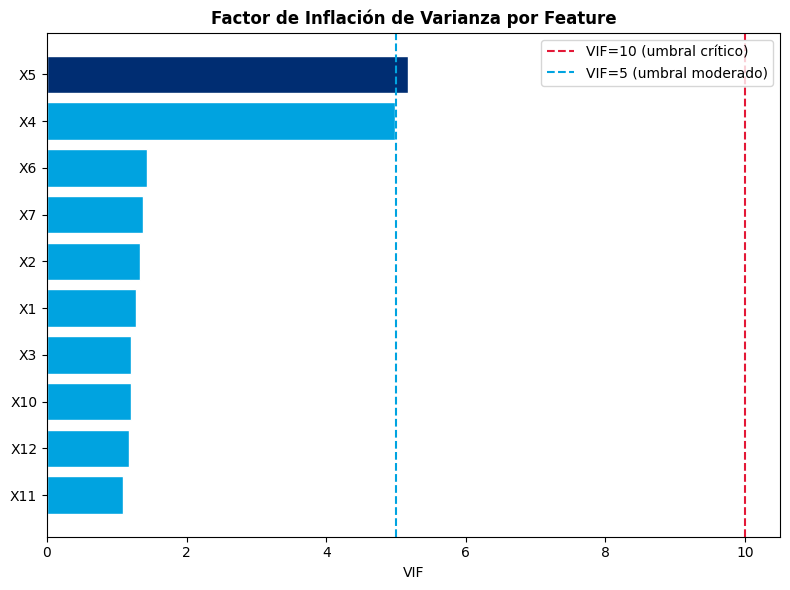

In [3]:
# Calcular VIF solo en columnas numéricas originales (excluir dummies X9 para visualización)
core_num_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X10', 'X11', 'X12',
                 'X3_missing', 'X4_missing', 'X5_missing']
core_available = [c for c in core_num_cols if c in X_train.columns]

vif_df = compute_vif(X_train[core_available])
display(vif_df)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [PALETTE[0] if v > 10 else PALETTE[1] if v > 5 else PALETTE[2]
          for v in vif_df['VIF']]
ax.barh(vif_df['feature'][::-1], vif_df['VIF'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(10, color=PALETTE[0], linestyle='--', label='VIF=10 (umbral crítico)')
ax.axvline(5, color=PALETTE[2], linestyle='--', label='VIF=5 (umbral moderado)')
ax.set_xlabel('VIF')
ax.set_title('Factor de Inflación de Varianza por Feature', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/03_vif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Ajuste del Modelo GLM

El proceso automático aplica:
1. Eliminación de features con VIF > 10
2. Backward elimination por p-value (umbral 5%)
3. OLS sobre log(TARGET)

In [4]:
glm = GLMRiskModel(vif_threshold=10.0, pvalue_threshold=0.05)
glm.fit(X_train, y_train, verbose=True)

Features iniciales: 47


Features tras VIF < 10.0: 34
Features tras backward elimination: 26
                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     716.1
Date:                Thu, 25 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:18:02   Log-Likelihood:                -25847.
No. Observations:               33334   AIC:                         5.175e+04
Df Residuals:                   33307   BIC:                         5.197e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [5]:
# Tabla de coeficientes con IC 95%
coef_df = glm.get_coefficients()
display(coef_df.style.background_gradient(
    subset=['coef'], cmap='RdBu_r', vmin=-1, vmax=1
).format({'coef': '{:.4f}', 'ci_lower': '{:.4f}', 'ci_upper': '{:.4f}', 'p_value': '{:.4f}'}))

,coef,ci_lower,ci_upper,p_value,significativo
const,5.2145,5.0608,5.3682,0.0000,True
X1,0.0000,0.0000,0.0000,0.0000,True
X2,-0.0000,-0.0000,-0.0000,0.0001,True
X3,-0.0000,-0.0000,-0.0000,0.0000,True
X4,0.0000,0.0000,0.0000,0.0000,True
X10,0.0000,0.0000,0.0000,0.0000,True
X4_sin_registro,0.0277,0.0022,0.0531,0.0331,True
X12_sin_registro,0.1575,0.1043,0.2107,0.0000,True
X2_sin_dato,-0.2299,-0.2558,-0.2039,0.0000,True
X7_sin_dato,-0.1345,-0.1925,-0.0765,0.0000,True


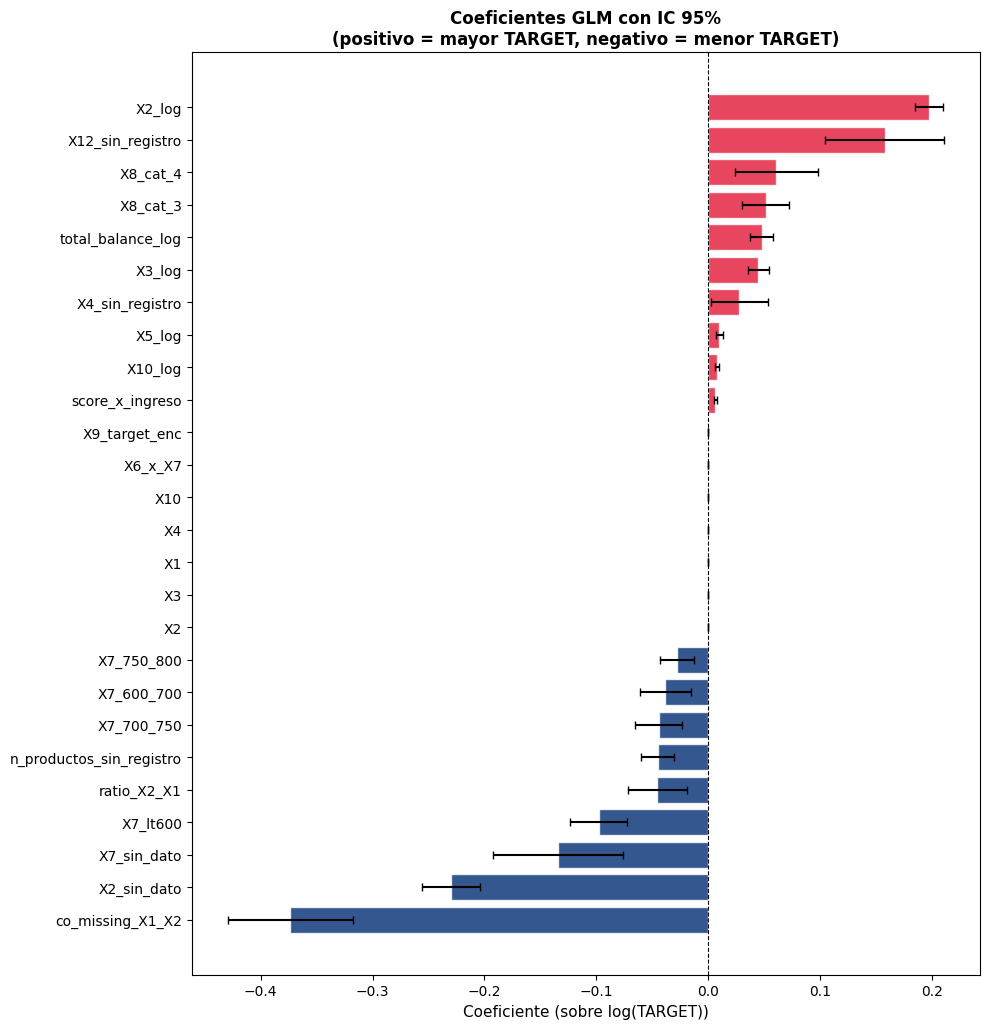

In [6]:
# Forest plot de coeficientes con intervalos de confianza
coef_plot = coef_df.drop('const', errors='ignore').copy()
coef_plot = coef_plot.sort_values('coef')

fig, ax = plt.subplots(figsize=(10, max(6, len(coef_plot) * 0.4)))

colors = [PALETTE[0] if v > 0 else PALETTE[1] for v in coef_plot['coef']]
ax.barh(coef_plot.index, coef_plot['coef'], xerr=[
    coef_plot['coef'] - coef_plot['ci_lower'],
    coef_plot['ci_upper'] - coef_plot['coef']
], color=colors, alpha=0.8, edgecolor='white', capsize=3)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coeficiente (sobre log(TARGET))', fontsize=11)
ax.set_title('Coeficientes GLM con IC 95%\n(positivo = mayor TARGET, negativo = menor TARGET)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_glm_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Verificación de Supuestos del Modelo Lineal

Los supuestos de OLS son: **L**inealidad, **I**ndependencia, **H**omocedasticidad,
**N**ormalidad de residuos (LIHN). Se evalúan visualmente y con tests estadísticos.

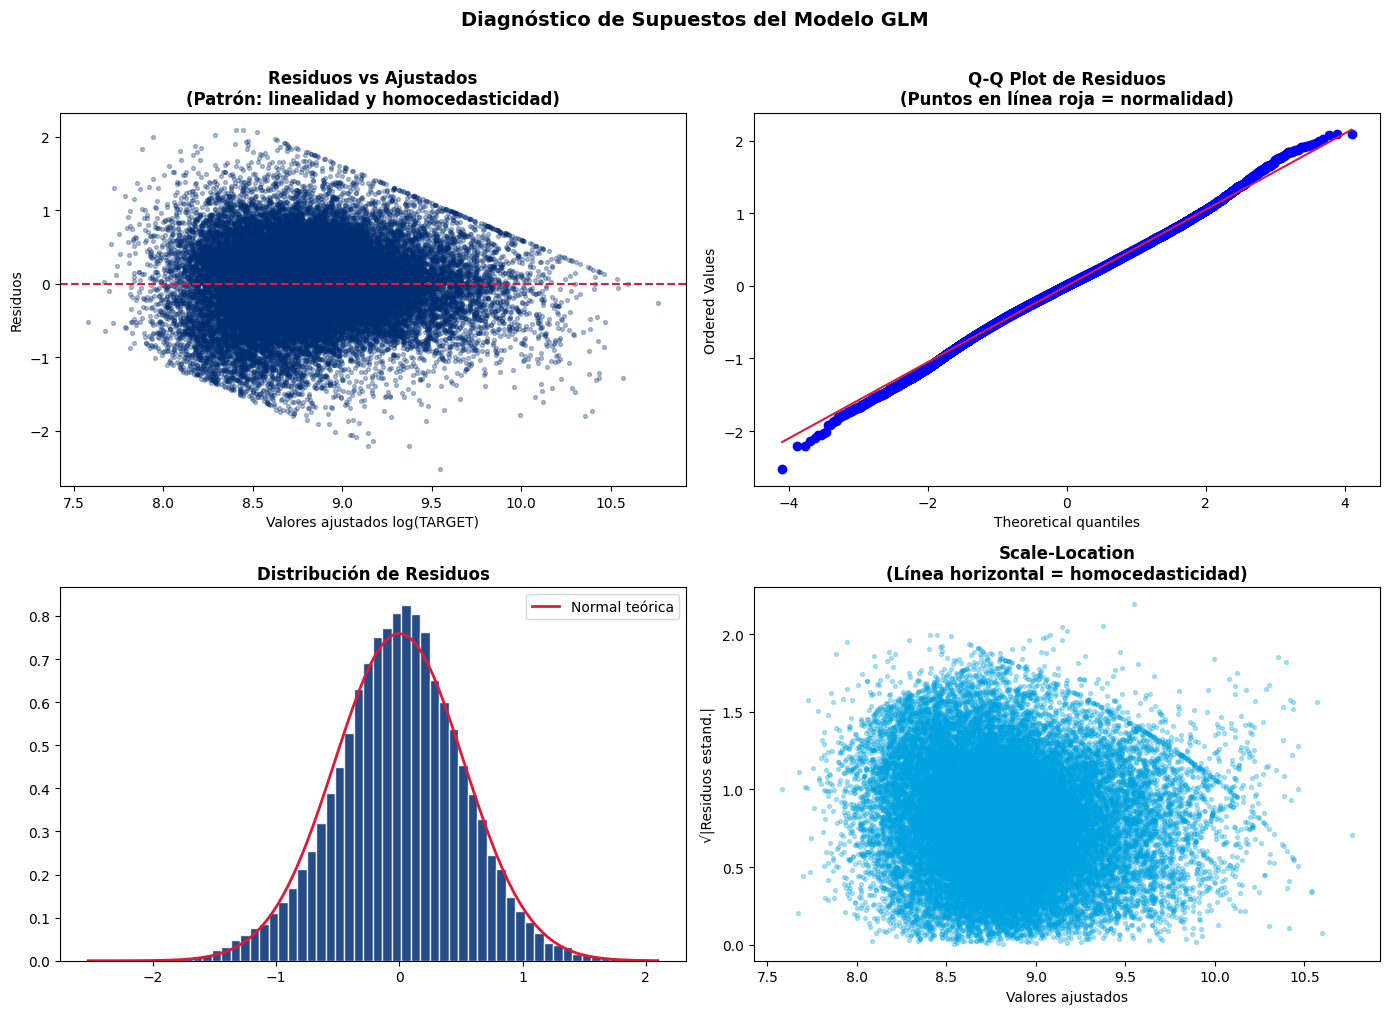

In [7]:
residuals = glm.model_.resid
fitted = glm.model_.fittedvalues  # predicciones en escala log

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores ajustados (linealidad y homocedasticidad)
axes[0, 0].scatter(fitted, residuals, alpha=0.3, s=8, color=PALETTE[1])
axes[0, 0].axhline(0, color=PALETTE[0], linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Valores ajustados log(TARGET)')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Ajustados\n(Patrón: linealidad y homocedasticidad)',
                      fontweight='bold')

# 2. Q-Q Plot (normalidad de residuos)
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot de Residuos\n(Puntos en línea roja = normalidad)', fontweight='bold')
axes[0, 1].get_lines()[1].set_color(PALETTE[0])

# 3. Histograma de residuos
axes[1, 0].hist(residuals, bins=60, color=PALETTE[1], edgecolor='white', alpha=0.85, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 0].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
                color=PALETTE[0], linewidth=2, label='Normal teórica')
axes[1, 0].set_title('Distribución de Residuos', fontweight='bold')
axes[1, 0].legend()

# 4. Scale-Location (raíz de residuos estandarizados vs ajustados)
standardized_resid = residuals / residuals.std()
axes[1, 1].scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.3, s=8, color=PALETTE[2])
axes[1, 1].set_xlabel('Valores ajustados')
axes[1, 1].set_ylabel('√|Residuos estand.|')
axes[1, 1].set_title('Scale-Location\n(Línea horizontal = homocedasticidad)', fontweight='bold')

plt.suptitle('Diagnóstico de Supuestos del Modelo GLM', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/03_glm_assumptions.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Tests estadísticos de supuestos
X_sel = X_train[glm.selected_features_]
tests = assumption_tests(glm.model_, X_sel, np.log(y_train))

print('=' * 60)
print('TESTS ESTADÍSTICOS DE SUPUESTOS')
print('=' * 60)

jb = tests['jarque_bera']
print(f'\n Normalidad de residuos (Jarque-Bera)')
print(f'   Estadístico: {jb["statistic"]}  |  p-valor: {jb["p_value"]}')
print(f'   Skewness: {jb["skewness"]}  |  Kurtosis: {jb["kurtosis"]}')
print(f'   Supuesto cumplido: {"OK" if jb["cumple_supuesto"] else ""}')
if not jb['cumple_supuesto']:
    print('   → Con 33K obs, el rechazo de normalidad es esperable (test muy potente).')
    print('     Verificar Q-Q plot — si la desviación es leve, los resultados son robustos.')

bp = tests['breusch_pagan']
print(f'\n Homocedasticidad (Breusch-Pagan)')
print(f'   Estadístico: {bp["statistic"]}  |  p-valor: {bp["p_value"]}')
print(f'   Supuesto cumplido: {"OK" if bp["cumple_supuesto"] else ""}')
if not bp['cumple_supuesto']:
    print('   → Heterocedasticidad detectada. Impacto: IC y p-valores son imprecisos.')
    print('     Mitigación: usar errores estándar robustos (HC3) o WLS.')

dw = tests['durbin_watson']
print(f'\n Autocorrelación (Durbin-Watson)')
print(f'   Estadístico: {dw["statistic"]}  (rango ideal: 1.5–2.5)')
print(f'   Supuesto cumplido: {"OK" if dw["cumple_supuesto"] else ""}')

TESTS ESTADÍSTICOS DE SUPUESTOS

 Normalidad de residuos (Jarque-Bera)
   Estadístico: 265.018  |  p-valor: 0.0
   Skewness: -0.074  |  Kurtosis: 0.411
   Supuesto cumplido: 
   → Con 33K obs, el rechazo de normalidad es esperable (test muy potente).
     Verificar Q-Q plot — si la desviación es leve, los resultados son robustos.

 Homocedasticidad (Breusch-Pagan)
   Estadístico: 2743.0237  |  p-valor: 0.0
   Supuesto cumplido: 
   → Heterocedasticidad detectada. Impacto: IC y p-valores son imprecisos.
     Mitigación: usar errores estándar robustos (HC3) o WLS.

 Autocorrelación (Durbin-Watson)
   Estadístico: 1.9937  (rango ideal: 1.5–2.5)
   Supuesto cumplido: OK


## 5. Métricas de Rendimiento

In [9]:
y_train_pred = glm.predict(X_train)
y_test_pred = glm.predict(X_test)

train_metrics = regression_metrics(y_train, y_train_pred, prefix='train_')
test_metrics = regression_metrics(y_test, y_test_pred, prefix='test_')

train_metrics['train_Gini'] = gini_coefficient(y_train.values, y_train_pred)
train_metrics['train_KS'] = ks_statistic(y_train.values, y_train_pred)
test_metrics['test_Gini'] = gini_coefficient(y_test.values, y_test_pred)
test_metrics['test_KS'] = ks_statistic(y_test.values, y_test_pred)

print('=== MÉTRICAS GLM ===')
print('\nTRAIN:')
for k, v in train_metrics.items():
    print(f'  {k}: {v}')
print('\nTEST:')
for k, v in test_metrics.items():
    print(f'  {k}: {v}')

# Gap RMSE (indicador de overfitting)
gap = (train_metrics['train_RMSE'] - test_metrics['test_RMSE']) / train_metrics['train_RMSE'] * 100
print(f'\nGap RMSE (train vs test): {gap:.1f}%')
print('Modelo estable' if abs(gap) < 10 else 'Posible overfitting/underfitting')

=== MÉTRICAS GLM ===

TRAIN:
  train_RMSE: 4980.97
  train_MAE: 3226.01
  train_R2: 0.3022
  train_MAPE_%: 45.74
  train_Gini: 0.5644
  train_KS: 0.4246

TEST:
  test_RMSE: 4951.16
  test_MAE: 3224.94
  test_R2: 0.2911
  test_MAPE_%: 44.94
  test_Gini: 0.5449
  test_KS: 0.4124

Gap RMSE (train vs test): 0.6%
Modelo estable


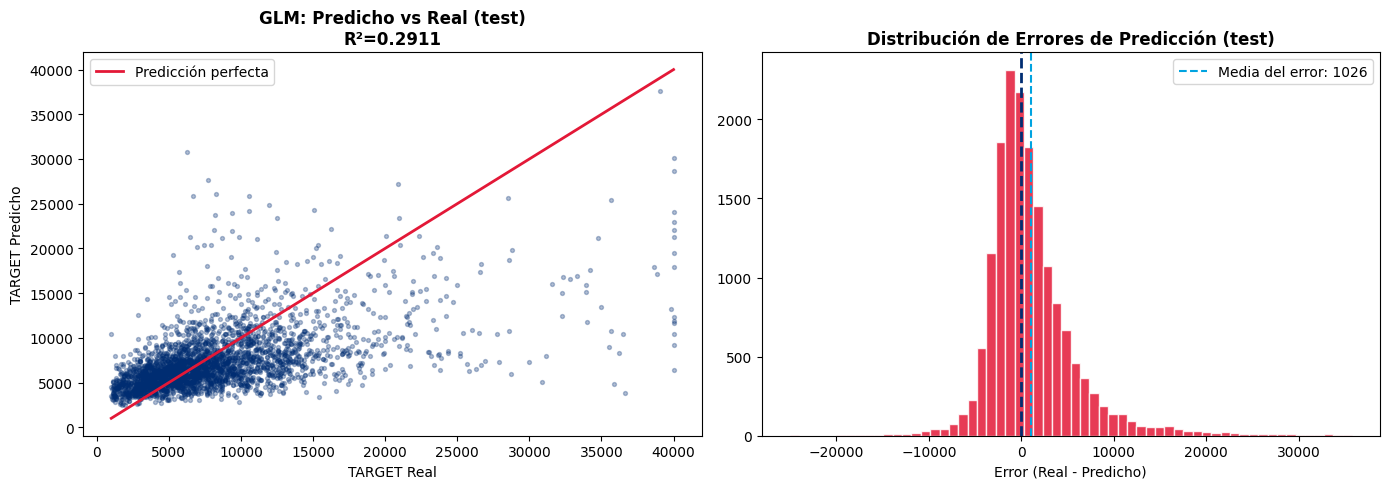

In [10]:
# Gráfico predicciones vs valores reales (test set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter predicho vs real
sample_idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_test_pred[sample_idx],
                alpha=0.3, s=8, color=PALETTE[1])
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], color=PALETTE[0],
             linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('TARGET Real')
axes[0].set_ylabel('TARGET Predicho')
axes[0].set_title(f'GLM: Predicho vs Real (test)\nR²={test_metrics["test_R2"]}',
                  fontweight='bold')
axes[0].legend()

# Distribución de errores
errors = y_test.values - y_test_pred
axes[1].hist(errors, bins=60, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color=PALETTE[1], linestyle='--', linewidth=2)
axes[1].axvline(errors.mean(), color=PALETTE[2], linestyle='--',
                label=f'Media del error: {errors.mean():.0f}')
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_title('Distribución de Errores de Predicción (test)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/03_glm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

=== ANÁLISIS POR DECIL (TEST) ===


,decile,n,mean_pred,mean_actual,min_pred,max_pred,error_pct
0,1,1667,3732.840000,4526.580000,1883.630000,4277.980000,-17.540000
1,2,1667,4647.030000,5411.970000,4278.060000,4963.080000,-14.130000
2,3,1666,5247.980000,6027.290000,4963.260000,5519.950000,-12.930000
3,4,1667,5788.660000,6671.000000,5520.120000,6038.140000,-13.230000
4,5,1667,6300.900000,7240.990000,6038.620000,6567.760000,-12.980000
5,6,1666,6863.670000,7983.360000,6567.940000,7174.470000,-14.030000
6,7,1667,7552.790000,8877.440000,7174.520000,7959.590000,-14.920000
7,8,1666,8491.120000,10053.860000,7959.730000,9135.080000,-15.540000
8,9,1667,10084.570000,11360.100000,9136.130000,11337.680000,-11.230000
9,10,1667,15305.420000,16118.340000,11339.060000,38285.480000,-5.040000


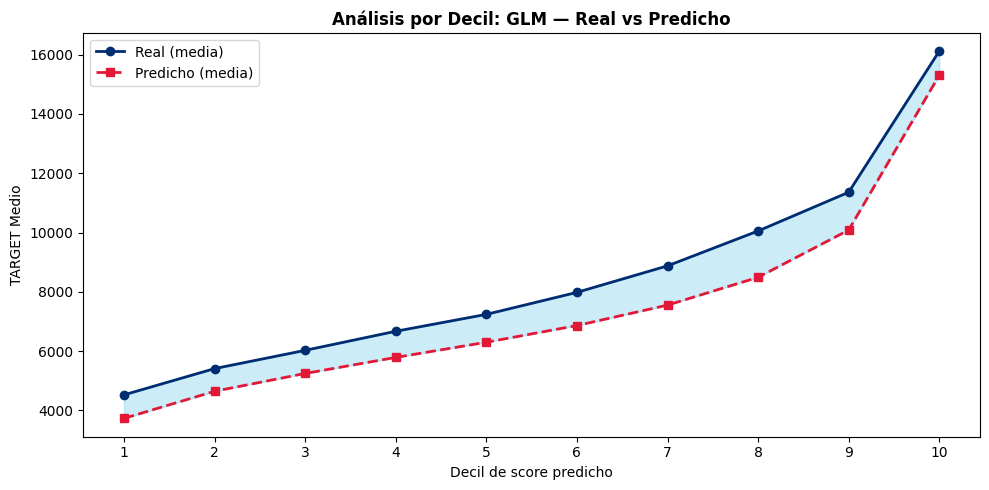

In [11]:
# Tabla de análisis por decil — validación del rank-ordering
decile_df = decile_table(y_test.values, y_test_pred)

print('=== ANÁLISIS POR DECIL (TEST) ===')
display(decile_df.style.background_gradient(subset=['error_pct'], cmap='RdYlGn_r'))

# Gráfico de deciles
fig, ax = plt.subplots(figsize=(10, 5))
x = decile_df['decile']
ax.plot(x, decile_df['mean_actual'], 'o-', color=PALETTE[1], label='Real (media)', linewidth=2)
ax.plot(x, decile_df['mean_pred'], 's--', color=PALETTE[0], label='Predicho (media)', linewidth=2)
ax.fill_between(x, decile_df['mean_actual'], decile_df['mean_pred'], alpha=0.2, color=PALETTE[2])
ax.set_xlabel('Decil de score predicho')
ax.set_ylabel('TARGET Medio')
ax.set_title('Análisis por Decil: GLM — Real vs Predicho', fontweight='bold')
ax.legend()
ax.set_xticks(x)
plt.tight_layout()
plt.savefig('../reports/figures/03_glm_decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Interpretación de Coeficientes

En un modelo log-lineal (OLS sobre log(TARGET)), los coeficientes se interpretan como:
- **Variables numéricas:** un incremento de 1 unidad en X_i cambia el TARGET en ~β_i × 100%
  (para valores pequeños de β_i, esta es la aproximación).
- **Variables dummy (X9):** el efecto multiplicativo de pertenecer a ese distrito vs la categoría de referencia.

In [12]:
coef_df = glm.get_coefficients().drop('const', errors='ignore')
coef_df['efecto_pct'] = ((np.exp(coef_df['coef']) - 1) * 100).round(2)

print('Interpretación de coeficientes (efecto % sobre TARGET):')
print('(Un incremento de 1 unidad en la variable → X% de cambio en TARGET)\n')

display(coef_df[['coef', 'efecto_pct', 'p_value', 'significativo']].sort_values(
    'efecto_pct', key=abs, ascending=False
).head(15))

Interpretación de coeficientes (efecto % sobre TARGET):
(Un incremento de 1 unidad en la variable → X% de cambio en TARGET)



,coef,efecto_pct,p_value,significativo
co_missing_X1_X2,-0.373549,-31.17,0.000000,True
X2_log,0.197226,21.80,0.000000,True
X2_sin_dato,-0.229851,-20.53,0.000000,True
X12_sin_registro,0.157498,17.06,0.000000,True
X7_sin_dato,-0.134462,-12.58,0.000006,True
X7_lt600,-0.098035,-9.34,0.000000,True
X8_cat_4,0.060690,6.26,0.001319,True
X8_cat_3,0.051158,5.25,0.000002,True
total_balance_log,0.047610,4.88,0.000000,True
X3_log,0.044777,4.58,0.000000,True


## 7. Serialización del Modelo

In [13]:
save_glm_model(glm, MODELS_DIR / 'glm_model.pkl')
print(f'Modelo GLM guardado en models/glm_model.pkl')
print(f'   Features seleccionadas: {glm.selected_features_}')
print(f'   R² (test): {test_metrics["test_R2"]}')
print(f'   RMSE (test): {test_metrics["test_RMSE"]:,.0f}')
print('\n→ El siguiente paso es 04_ml_model_lgbm.ipynb')

Modelo GLM guardado en models/glm_model.pkl
   Features seleccionadas: ['X1', 'X2', 'X3', 'X4', 'X10', 'X4_sin_registro', 'X12_sin_registro', 'X2_sin_dato', 'X7_sin_dato', 'X2_log', 'X3_log', 'X5_log', 'X10_log', 'n_productos_sin_registro', 'total_balance_log', 'score_x_ingreso', 'ratio_X2_X1', 'co_missing_X1_X2', 'X6_x_X7', 'X7_600_700', 'X7_700_750', 'X7_750_800', 'X7_lt600', 'X8_cat_3', 'X8_cat_4', 'X9_target_enc']
   R² (test): 0.2911
   RMSE (test): 4,951

→ El siguiente paso es 04_ml_model_lgbm.ipynb
